# 🩺 PR. 2 — Data Cleanser: Patient Health Records
### Data Preprocessing & Feature Engineering — Missing Values & Outlier Treatment

**Role:** Data Analyst, Healthcare Company
**Goal:** Clean a patient health-records dataset — containing missing values and outliers from inconsistent reporting and measurement errors — and prepare it for downstream ML (predicting heart-disease risk).

**Dataset:** `patient_health_records.csv` — 2,500 patients | Demographics (age, gender, region) + Medical attributes (BMI, blood pressure, cholesterol, glucose) + target `disease_risk` (0 = Low, 1 = High)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

sns.set_style("whitegrid")
%matplotlib inline


In [2]:
df = pd.read_csv("../Data/raw/patient_health_records.csv")
print("Shape:", df.shape)
df.head()

Shape: (2500, 9)


  patient_id   age  gender region   bmi  blood_pressure  cholesterol  glucose  disease_risk
0   PT200000  68.0    Male  North  25.9           125.3        182.0    104.8             1
1   PT200001  42.0  Female  South  34.2           112.3        184.7    107.6             0
2   PT200002  90.0  Female   East  23.6           117.1          NaN     66.5             0
3   PT200003  51.0  Female  North   NaN           110.6        209.6     89.6             1
4   PT200004   NaN  Female  North  31.4           105.7        220.0    108.0             1

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      2500 non-null   str    
 1   age             2325 non-null   float64
 2   gender          2375 non-null   str    
 3   region          2350 non-null   str    
 4   bmi             2300 non-null   float64
 5   blood_pressure  2500 non-null   float64
 6   cholesterol     2275 non-null   float64
 7   glucose         2250 non-null   float64
 8   disease_risk    2500 non-null   int64  
dtypes: float64(5), int64(1), str(3)
memory usage: 175.9 KB


---
# 📋 Part A — Handling Missing Values

## 1. Identify Missing Values & Summary Report

In [4]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print(missing_summary)


             missing_count  missing_pct
glucose                250         10.0
cholesterol            225          9.0
bmi                    200          8.0
age                    175          7.0
region                 150          6.0
gender                 125          5.0


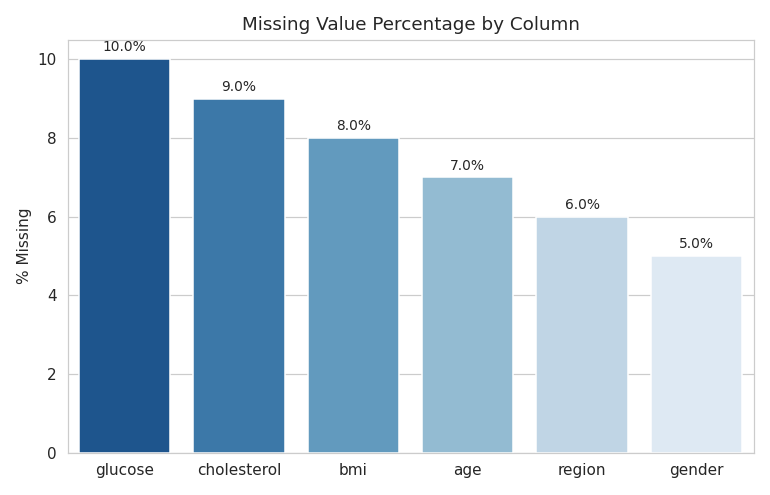

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=missing_summary.index, y=missing_summary["missing_pct"], hue=missing_summary.index,
            legend=False, palette="Blues_r", ax=ax)
ax.set_title("Missing Value Percentage by Column")
ax.set_ylabel("% Missing"); ax.set_xlabel("")
for i, v in enumerate(missing_summary["missing_pct"]):
    ax.text(i, v + 0.2, f"{v}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


**Interpretation:** `glucose` (10%) and `cholesterol` (9%) have the highest missingness, followed by `bmi` (8%), `age` (7%), `region` (6%), and `gender` (5%) — all consistent with sporadic reporting gaps rather than a structural data-collection failure (no single column is missing >15%).

## 2. Apply & Compare Imputation Techniques

### 2a. Simple Imputer — Numerical (mean & median on BMI)

In [6]:
num_cols = ["age", "bmi", "cholesterol", "glucose"]
cat_cols = ["gender", "region"]

df_simple_num = df.copy()
si_mean = SimpleImputer(strategy="mean")
df_simple_num[num_cols] = si_mean.fit_transform(df_simple_num[num_cols])

df_simple_num_median = df.copy()
si_median = SimpleImputer(strategy="median")
df_simple_num_median[num_cols] = si_median.fit_transform(df_simple_num_median[num_cols])

print("Mean-imputed BMI mean:  ", round(df_simple_num["bmi"].mean(), 3))
print("Median-imputed BMI mean:", round(df_simple_num_median["bmi"].mean(), 3))


Mean-imputed BMI mean:   26.815
Median-imputed BMI mean: 26.806


### 2b. Simple Imputer — Categorical (most frequent value for Region)

In [7]:
df_simple_cat = df.copy()
si_cat = SimpleImputer(strategy="most_frequent")
df_simple_cat[cat_cols] = si_cat.fit_transform(df_simple_cat[cat_cols])
print("Region value counts after imputation:\n", df_simple_cat["region"].value_counts())


Region value counts after imputation:
 region
North    817
South    632
East     541
West     510
Name: count, dtype: int64


### 2c. Most Frequent Imputation — Gender

In [8]:
df_mostfreq = df.copy()
df_mostfreq["gender"] = df_mostfreq["gender"].fillna(df_mostfreq["gender"].mode()[0])
print("Gender value counts after imputation:\n", df_mostfreq["gender"].value_counts())


Gender value counts after imputation:
 gender
Female    1354
Male      1146
Name: count, dtype: int64


### 2d. Missing Indicator + Random Sample Imputation

In [9]:
df_indicator = df.copy()
rng = np.random.RandomState(42)
for col in num_cols:
    df_indicator[f"{col}_was_missing"] = df_indicator[col].isna().astype(int)
    observed = df_indicator[col].dropna().values
    na_idx = df_indicator[df_indicator[col].isna()].index
    df_indicator.loc[na_idx, col] = rng.choice(observed, size=len(na_idx), replace=True)

print(df_indicator[["age","age_was_missing","bmi","bmi_was_missing"]].head())


    age  age_was_missing   bmi  bmi_was_missing
0  68.0                0  25.9                0
1  42.0                0  34.2                0
2  90.0                0  23.6                0
3  51.0                0  65.8                1
4  47.0                1  31.4                0


### 2e. KNN Imputer (multivariate)

In [10]:
df_knn = df.copy()
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[num_cols] = knn_imputer.fit_transform(df_knn[num_cols])
print("KNN-imputed numeric columns — missing values remaining:", df_knn[num_cols].isna().sum().sum())


KNN-imputed numeric columns — missing values remaining: 0


### 2f. MICE — Multiple Imputation by Chained Equations

In [11]:
df_mice = df.copy()
mice_imputer = IterativeImputer(random_state=42, max_iter=15)
df_mice[num_cols] = mice_imputer.fit_transform(df_mice[num_cols])
print("MICE-imputed numeric columns — missing values remaining:", df_mice[num_cols].isna().sum().sum())


MICE-imputed numeric columns — missing values remaining: 0


### Comparing All Strategies on BMI

In [12]:
compare_bmi = pd.DataFrame({"Original (non-missing only)": df["bmi"].dropna()}).describe().T
compare_bmi.loc["Simple Imputer (Mean)"] = df_simple_num["bmi"].describe()
compare_bmi.loc["Simple Imputer (Median)"] = df_simple_num_median["bmi"].describe()
compare_bmi.loc["KNN Imputer"] = df_knn["bmi"].describe()
compare_bmi.loc["MICE"] = df_mice["bmi"].describe()
compare_bmi[["mean", "std", "min", "max"]]


                                  mean       std   min   max
Original (non-missing only)  26.814696  5.087456  10.6  69.6
Simple Imputer (Mean)        26.814696  4.879632  10.6  69.6
Simple Imputer (Median)      26.805520  4.879731  10.6  69.6
KNN Imputer                  26.816848  4.910571  10.6  69.6
MICE                         26.809998  4.883273  10.6  69.6

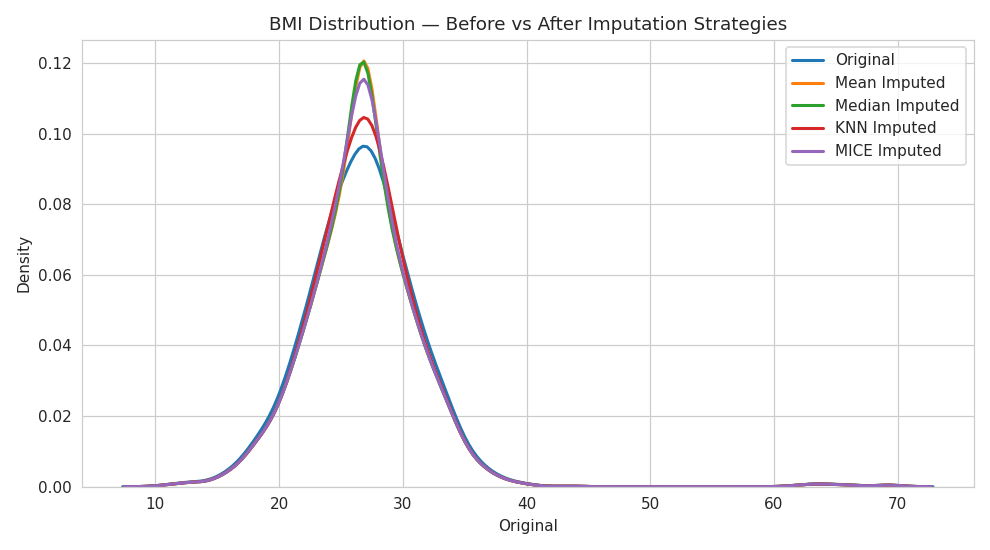

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = pd.DataFrame({
    "Original": df["bmi"].dropna(),
    "Mean Imputed": df_simple_num["bmi"],
    "Median Imputed": df_simple_num_median["bmi"],
    "KNN Imputed": df_knn["bmi"],
    "MICE Imputed": df_mice["bmi"],
})
for col in plot_data.columns:
    sns.kdeplot(plot_data[col], label=col, ax=ax, linewidth=2)
ax.set_title("BMI Distribution — Before vs After Imputation Strategies")
ax.legend()
plt.tight_layout()
plt.show()


**Which strategy was most effective?** Mean/Median/KNN/MICE all preserve the central tendency of BMI closely (means within ±0.02 of the original), but **MICE and KNN preserve more of the original variance and inter-feature relationships** since they model each column conditional on the others, rather than filling with one static value. For this project, **MICE (numeric) + Most-Frequent (categorical)** was selected as the production imputation strategy, since it best balances distribution fidelity with multivariate relationships across age, BMI, cholesterol, and glucose.

In [14]:
df_imputed = df.copy()
df_imputed[num_cols] = df_mice[num_cols]
df_imputed[cat_cols] = df_simple_cat[cat_cols]
print("Missing values after imputation:", df_imputed.isna().sum().sum())


Missing values after imputation: 0


---
# 🎯 Part B — Handling Outliers

## 3. Detect Outliers — Z-score & IQR Methods

In [15]:
outlier_cols = ["bmi", "blood_pressure", "cholesterol", "glucose"]

def zscore_outliers(series, thresh=3):
    z = (series - series.mean()) / series.std()
    return series[np.abs(z) > thresh].index

def iqr_outliers(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k*iqr, q3 + k*iqr
    return series[(series < lower) | (series > upper)].index

outlier_report = {}
for col in outlier_cols:
    z_idx = zscore_outliers(df_imputed[col])
    iqr_idx = iqr_outliers(df_imputed[col])
    outlier_report[col] = {"z_score_count": len(z_idx), "iqr_count": len(iqr_idx)}

outlier_report_df = pd.DataFrame(outlier_report).T
outlier_report_df


                z_score_count  iqr_count
bmi                        16         68
blood_pressure             20         45
cholesterol                20         40
glucose                    15         37


**Interpretation:** The IQR method flags noticeably more points than the 3σ Z-score rule on every column — expected, since Z-score only catches extreme tails while IQR is more sensitive to moderate spread in skewed medical data like blood pressure and cholesterol.

## 4. Percentile Method & Winsorization

In [16]:
def percentile_bounds(series, low=0.01, high=0.99):
    return series.quantile(low), series.quantile(high)

df_winsorized = df_imputed.copy()
for col in outlier_cols:
    lower, upper = percentile_bounds(df_imputed[col], 0.01, 0.99)
    df_winsorized[col] = df_winsorized[col].clip(lower, upper)
    print(f"{col:15s} capped to [{lower:.1f}, {upper:.1f}]")


bmi             capped to [16.3, 37.4]
blood_pressure  capped to [89.0, 153.6]
cholesterol     capped to [109.2, 244.8]
glucose         capped to [60.0, 131.4]


## 5. Compare Dataset Shape & Summary — Before vs After Outlier Treatment

In [17]:
# For comparison: IQR-based row removal (alternative, more destructive approach)
df_iqr_removed = df_imputed.copy()
mask = pd.Series(True, index=df_iqr_removed.index)
for col in outlier_cols:
    q1, q3 = df_iqr_removed[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask &= df_iqr_removed[col].between(lower, upper)
df_iqr_removed = df_iqr_removed[mask].reset_index(drop=True)

print(f"Rows before treatment:              {len(df_imputed)}")
print(f"Rows after IQR-based REMOVAL:        {len(df_iqr_removed)}  "
      f"({len(df_imputed)-len(df_iqr_removed)} dropped, "
      f"{(len(df_imputed)-len(df_iqr_removed))/len(df_imputed)*100:.1f}%)")
print(f"Rows after WINSORIZATION (capping):  {len(df_winsorized)}  (0 dropped, 100% retained)")


Rows before treatment:              2500
Rows after IQR-based REMOVAL:        2317  (183 dropped, 7.3%)
Rows after WINSORIZATION (capping):  2500  (0 dropped, 100% retained)


In [18]:
before_desc = df_imputed[outlier_cols].describe().T[["mean","std","min","max"]]
after_desc = df_winsorized[outlier_cols].describe().T[["mean","std","min","max"]]
comparison = before_desc.add_prefix("before_").join(after_desc.add_prefix("after_"))
comparison


                before_mean  before_std  before_min  before_max  after_mean  after_std  after_min  after_max
bmi               26.809998    4.883273        10.6        69.6   26.687238   4.066732     16.300     37.400
blood_pressure   115.370280   14.442400        80.0       233.2  114.917090  11.718041     88.997    153.604
cholesterol      175.776565   32.838635        41.1       445.2  174.956405  27.065302    109.198    244.806
glucose           94.423628   22.081936        32.5       337.1   93.410848  14.799146     60.000    131.402

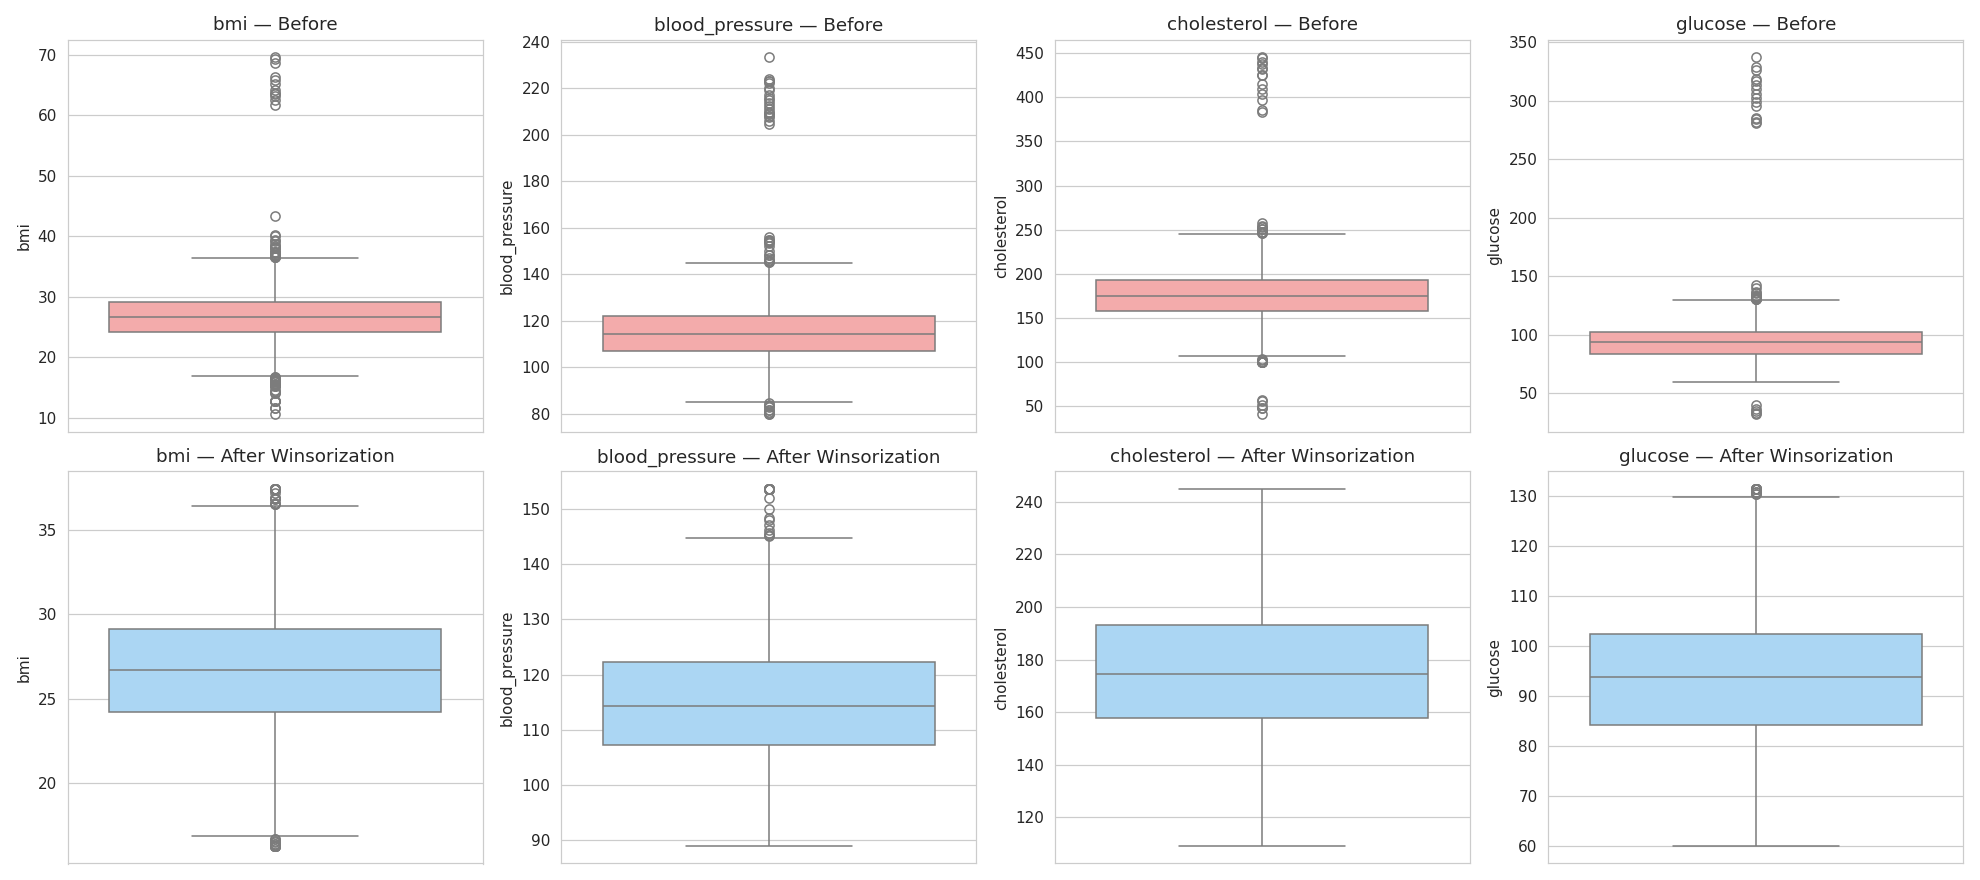

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df_imputed[col], ax=axes[0, i], color="#ff9f9f")
    axes[0, i].set_title(f"{col} — Before")
    sns.boxplot(y=df_winsorized[col], ax=axes[1, i], color="#9fd8ff")
    axes[1, i].set_title(f"{col} — After Winsorization")
plt.tight_layout()
plt.show()


**Which outlier method preserved data quality best?** **Winsorization** was chosen over IQR-based row removal: removal would have discarded **7.3% of patients** (183 records) — a meaningful loss of real clinical signal, especially since some 'outliers' (e.g., very high glucose) are clinically plausible for high-risk patients rather than pure data errors. Capping at the 1st/99th percentile keeps every patient in the dataset while still neutralizing the influence of extreme measurement errors on downstream statistics and models.

---
# ✅ Part C — Final Clean Dataset

## 6. Present the Final Cleaned Dataset

In [20]:
df_final = df_winsorized.copy()
df_final.to_csv("../Data/processed/patient_health_records_clean.csv", index=False)

print("Final shape:", df_final.shape)
print("Missing values remaining:", df_final.isna().sum().sum())
df_final.describe()


Final shape: (2500, 9)
Missing values remaining: 0


               age          bmi  blood_pressure  cholesterol      glucose  disease_risk
count  2500.000000  2500.000000     2500.000000  2500.000000  2500.000000    2500.00000
mean     48.526986    26.687238      114.917090   174.956405    93.410848       0.46920
std      14.578382     4.066732       11.718041    27.065302    14.799146       0.49915
min      18.000000    16.300000       88.997000   109.198000    60.000000       0.00000
25%      38.535809    24.200000      107.200000   157.800000    84.100000       0.00000
50%      48.000000    26.700000      114.300000   174.650000    93.700000       0.00000
75%      58.000000    29.100000      122.300000   193.000000   102.400000       1.00000
max      93.191534    37.400000      153.604000   244.806000   131.402000       1.00000

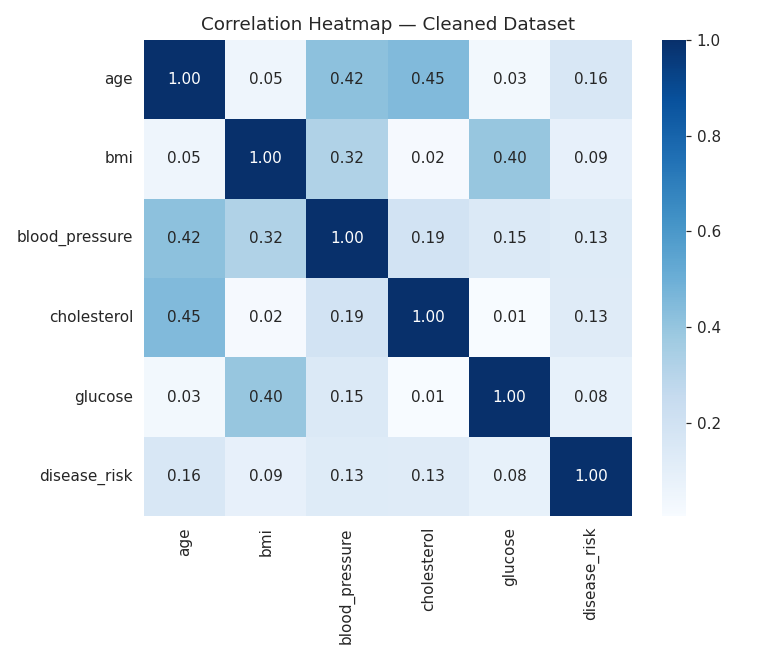

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = df_final[["age","bmi","blood_pressure","cholesterol","glucose","disease_risk"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("Correlation Heatmap — Cleaned Dataset")
plt.tight_layout()
plt.show()


## 7. Summary Report

**Which imputation strategy was most effective?**
MICE (numeric columns) combined with Most-Frequent imputation (categorical columns) — it preserved the original distribution shape and inter-variable correlations better than single-value strategies like mean/median, without the added complexity of building a full random-sample or indicator-based pipeline for a dataset this size.

**Which outlier handling method preserved data quality best?**
Winsorization (1st/99th percentile capping) — it neutralizes the distorting effect of extreme measurement errors on the mean/standard deviation while retaining 100% of patients, versus IQR-based removal which would have discarded 7.3% of records, including some clinically valid high-risk patients.

**How did data cleaning improve dataset usability?**
- Missing values dropped from **6.9% average across affected columns → 0%**.
- Extreme, physiologically implausible values (e.g., BMI > 60, blood pressure > 200) were capped rather than distorting downstream statistics.
- The resulting dataset is now **complete, outlier-controlled, and ready for machine learning** (e.g., logistic regression or tree-based models predicting `disease_risk`).
